<a href="https://colab.research.google.com/github/Bruno-Paulo/PETs/blob/main/Synthetic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Data Tutorial


_Last run: May 1, 2025_


## 1. Introduction

This scenario will illustrate the use synthetic data generation for privacy. We will create a dataset that can be shared with third-parties for analysis that  resembles the original data while preserving privacy. The new dataset is statistically similar to the original enabling statistical analysis and machine learning, but does not include any actual identifiable information.

### 1.1 Scenario

Consider a healthcare company (let’s call it LifeMed) that specialises in predictive analytics to improve patient care. This company uses machine learning models to identify patients at risk of stroke based on their medical history, health indicators and lifestyle factors.
The company needs to share their dataset with an external research organisation that is working on an advanced stroke prevention techniques to improve the accuracy of the predictive analytics. However, sharing the raw data poses significant privacy risks due to the sensitivity of patient information and the constraints posed by compliance with laws such as GDPR and HIPAA.


### 1.2 Solution

Synthetic data enables the external organisation to train machine learning models while protecting LifeMed's patient privacy. By generating realistic datasets that resemble the original data, analysts can maintain high model performance without risking exposure of sensitive data.

### 1.3 Synthetic Data

Synthetic data is algorithmically created data that mimics real-world data. This data can be used to create new data for software testing purposes or to create new datasets with very similar patterns, properties, and statistical distributions of the original data. In summary, the main applications of synthetic data are as follows:

- **Data augmentation:** Small datasets are augmented for testing or training machine learning models.

- **Private data sharing:** Generated datasets enables data to be shared for analysis and without exposing sensitive information.

An important property of synthetic data is the ability to replace sensitive data sets for many activities enabling organisations to comply with regulations data privacy such as GDPR and HIPAA.


### 1.4 Outline of this tutorial

By the end of this tutorial, you will have a solid foundation for generating synthetic datasets and using SDV's advanced features to address privacy, compliance, and scalability challenges.

#### **Generate a synthetic dataset from an original one**
We will learn how to create synthetic data for sharing. We will do that by starting with an original table containing information about patient data and then generating a new table with synthetic data.

#### **Evaluate the quality of the synthetically generated dataset**
The next step will be evaluating the generated table and comparing it to the original. The idea here is to validate that a model thus created preserves statistical properties and does not expose any personal information.

#### **Illustrate the feasibility of training a classifier model on the synthetic data**
Finally, we will learn how to create a classifier model by training it on the synthetic data and comparing its performance with the same model trained on the original dataset to see the difference.


## 2. Setup

In order to create the synthetic dataset we will need to download the original data and then configure the Python library that will assist in the synthesis.


---


***Note:*** This code will only work correctly if you use the Google
Chrome browser.



---





### 2.1 Downloading the original dataset

Please download the healthcare dataset in CSV file format from [here](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset).

Now we need attach the CSVs to this Google Colab notebook. Run the code below and then Click the "Choose Files" button. In the file picker choose the CSV file that you have just downloaded.


In [ ]:
from google.colab import files

# Optional: You can skip this step if you are running the code on your own
# machine
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


The csv files are now available in the folder `content/`.

### 2.2 Installing the SDV library

The Synthetic Data Vault (SDV) is a comprehensive Python library that streamlines the generation of synthetic data. SDV provides tools to:

- Model complex, multi-table datasets and their relationships.
Automatically or manually discover and define metadata for datasets.

- Generate synthetic data that retains the statistical properties of the original data.

- Evaluate the quality of synthetic data using advanced diagnostic tools.

If you need more help [Browse all tutorials](https://docs.sdv.dev/sdv/demos) or visit the [full documentation](https://docs.sdv.dev/sdv).

To install the SDV library, run the following:




In [ ]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8

## 3. Loading the Dataset

Now we can use the built-in SDV function to read all the csv files in a folder.


In [ ]:
from sdv.datasets.local import load_csvs
from sdv.datasets.demo import download_demo

try:
  # This is the default folder name that the Google Colab notebook uses.
  # Change this if you have your own folder with CSV files.
  data = load_csvs(folder_name='/content/')
except ValueError:
  print('You have not uploaded any csv files.')

We should have ended up with dictionary datasets that maps table names (in our case, CSV files) to the actual data in memory.


In [ ]:
data.keys()

dict_keys(['healthcare-dataset-stroke-data'])

The data is loaded as a `pandas.DataFrame` object. SDV manipulates Pandas data frame objects for convenience.

Let's look at this object in detail.

In [ ]:
healthcare_table = data['healthcare-dataset-stroke-data']

# Preview the first few rows
print(healthcare_table.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


## 4. Creating the Metadata

The SDV requires a description of the types of data in each column of the data set. This data about data is also known as **metadata**. Metadata will be used by SDV to create different and more accurate data for synthetic columns.

When multiple tables are present, metadata will also describe how the tables are connected to each other.



### 4.1 Autodetect existing Metadata

The easiest way to create our metadata object is by auto-detecting it from our data.

Each column will be associated with a data type object (of type `sdtype`) that describes the data.

We will find two fundamental `sdtypes`, namely:

- Statistical `sdtypes` such as `categorical`, `datetime` and `numerical` provide more general information about the type of data.

- Semantic `sdtypes` such as `credit_card_number` and `city` provide higher level information that is understandable to humans.

For more information, see the [sdtypes docs page](https://docs.sdv.dev/sdv/reference/metadata-spec/sdtypes).

Lets us now perform the auto detection and then inspect the result.

Auto detected data:



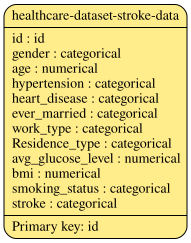

In [ ]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

print('Auto detected data:\n')
metadata.visualize()



---


***Note:*** According to SDV, the detected metadata is not guaranteed to be accurate or complete.


---



### 4.2 Fixing and refining data types in metadata

Whenever we have a column metadata is marked as `unknown`, we should assign a correct `sdtype` to it.

Also metadata must be refined. For example, SDV will do a better job knowing that a text column is a city name or a person name. Other types such as `city` or `credit_card_number` can be assigned to a column for better modeling.

Some data types are considered **PII**, meaning that SDV will anonymize these columns (we can turn this off and use the original values by setting the PII flag to False).

***Note:*** In case of this dataset there are no unknown sdtype, and because of this we do not need to do any modifications. If you ever run into this situation you need to find out what is most appropriate sdtype. For more information pease consult this [tutorial](https://colab.research.google.com/drive/1DlUlHNohxBhxN6GA5C_C4Fd9wx5AR11Y?usp=sharing) by the creators of the SDV library.




### 4.3 Validating the metadata

Metadata should be accurate. This means that each column only contains valid values according to the datatype of the column.  

Since sdtypes objects can be created and associated to the columns programmatically, it is a good idea to validate that the metadata is still valid for the data loaded by checking all the values.

We can also validate that the metadata accurately matches the data that we provided. The code below should run without any errors.


In [ ]:
metadata.validate()
metadata.validate_data(data=data)

Finally, we can also visualise the final structure data and validate visually that the column types are correct.

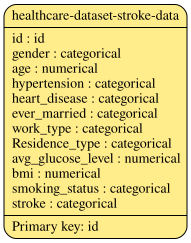

In [ ]:
metadata.visualize()

### 4.4 Saving the Metadata

It is also a good practice to save the metadata as a `JSON` object so that we can re-use this description later whenever we need to.

In [ ]:
try:
  metadata.save_to_json('metadata.json')
except ValueError:
  print('A file named "metadata.json" already exists in this folder.')
  print('We will delete it first and then create a new one.')
  %rm /content/metadata.json
  metadata.save_to_json('metadata.json')

# in the future, you can reload the metadata object from the file
metadata = Metadata.load_from_json('metadata.json')

## 5. Creating Synthetic Data
With these preparatory steps completed, we can now manipulate the data along with the metadata description in SDV.


### 5.1 Creating the data synthesiser

A **synthesiser** is an object that generates synthetic data. It learns patterns from the real data and replicates them in the output synthetic data.



---



***Note:*** The synthesiser will generate synthetic records in the same format as the original data.



---



In SDV, we can create a synthetiser object by specifying the data table and the corresponding metadata as follows:




In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(healthcare_table)

### 5.2 Generating the synthetic data

We generate data by invoking the `sample` function of the synthetiser object. We should pass the `num_rows` we want to synthetise. If we want the same number of rows of the original data set we should specify `len(healthcare_table)`.

In [ ]:
synthetic_data = synthesizer.sample(num_rows=len(healthcare_table))

synthetic_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,3525996,Female,69.41,0,0,Yes,Private,Rural,127.58,34.5,formerly smoked,0
1,4651427,Male,4.41,0,0,No,children,Rural,61.60,21.0,Unknown,0
2,13030739,Male,21.51,0,0,No,children,Rural,66.84,21.9,Unknown,0
3,9215219,Male,30.49,0,1,Yes,Private,Rural,130.65,36.7,never smoked,0
4,10439349,Male,16.94,0,0,Yes,Private,Rural,103.82,26.9,smokes,0


### 5.3 Validating the synthetic dataset

It is essential to ensure that the synthetic dataset aligns with the metadata specifications of the original dataset and maintains statistical validity.
To do that, we will start by running a diagnostic on the metadata. This diagnostic will check, among other things:

- All primary keys are unique.
- Numeric values must adhere to the min/max of the real data.
- Discrete columns (non-PII) have the same categories as the real data.

To do that, run the run_diagnostic function as follows:


In [ ]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 305.49it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 108.47it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%





---


***Note:*** A score of 100% indicates that the values in the synthetised data ser are fully valid.  



---



Now, we can also measure the **data quality** with the respect to the statistical similarity between the real and synthetic data. We use this to discover which patterns the synthetic data has captured from the real data.

Execute the `evaluate_quality` function as follows:


In [ ]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    healthcare_table,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 70.82it/s]|
Column Shapes Score: 96.97%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 76.65it/s]|
Column Pair Trends Score: 86.83%

Overall Score (Average): 91.9%





---


***Note:***
The score will vary from 0% to 100%. This value tells you how similar the synthetic data is to the real data.

- A score of 100% means that the patterns are exactly the same. For example, if you compared the real data to itself (identity), the score would be 100%.

- A score of 0% means that the patterns are as different as possible. This would mean that the synthetic data deliberately contains anti-patterns that are opposite to the real data.

- Any score in the middle can be interpreted along this scale. For example, a score of 80% means that the synthetic data is about 80% similar to the real data - about 80% of the trends are similar.

The quality score is expected to vary and you may never get exactly 100% quality. That's OK! The SDV synthesisers are designed to estimate patterns, which means that they may smooth, extrapolate or noise certain parts of the data.  See the [FAQs](https://docs.sdv.dev/sdv/multi-table-data/evaluation/data-quality#faqs) for more information.



---




As you will see from the output, the score shows that the statistical similarity of the the synthetic data to the original data set is about 92%.



## 6. Visualising generated data

In some situation we may need to understand the differences between synthetic and original data to ensure that the synthetic data remain useful for analysis without replicating the records of real individuals. For example, we can do the plot distributions of specific columns like `stroke` and `age` to visually validate similarity.


### 6.1 Checking the generated data

We can check and compare the original data with the synthetic generated data by printing out the first few rows of each.



---



***Note:***
Simply printing and comparing the first few rows of the original and synthetic data does not guarantee that the synthetic data is truly private. This is because privacy is a formal concept in the domain of Differential Privacy (DP), which provides mathematical guarantees that an individual's data cannot be inferred from the generated dataset.
For more information check the [differential privacy tutorial](https://colab.research.google.com/drive/1PdYvVmtGzZLRBkmDMk4jhJnFDUn9DPcR?usp=sharing)

---



#### 6.1.1 Original data

In [ ]:
healthcare_table.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


#### 6.1.2 Synthetic generated data

In [ ]:
synthetic_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,3525996,Female,69.41,0,0,Yes,Private,Rural,127.58,34.5,formerly smoked,0
1,4651427,Male,4.41,0,0,No,children,Rural,61.60,21.0,Unknown,0
2,13030739,Male,21.51,0,0,No,children,Rural,66.84,21.9,Unknown,0
3,9215219,Male,30.49,0,1,Yes,Private,Rural,130.65,36.7,never smoked,0
4,10439349,Male,16.94,0,0,Yes,Private,Rural,103.82,26.9,smokes,0


### 6.2 1D Visualisation

Let's perform a 1D visualization comparing each column of the original data to the corresponding column on the synthetic dataset.
We do this by creating figures from with the `get_column_plot` function.


In [ ]:
from sdv.evaluation.single_table import get_column_plot

# Plotting Stroke
fig = get_column_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    column_name='stroke',
    metadata=metadata
)

fig.show()


# Plotting Age
fig = get_column_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    column_name='age',
    metadata=metadata
)

fig.show()


# Plotting glucose level
fig = get_column_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    column_name='avg_glucose_level',
    metadata=metadata
)

fig.show()


# Plotting bmi
fig = get_column_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    column_name='bmi',
    metadata=metadata
)

fig.show()

### 6.3 2D Visualisation

We can also do it in 2D comparing the correlations of a pair of columns.

We do this by creating figures from with the `get_column_pait_plot` function as follows.


In [ ]:
from sdv.evaluation.single_table import get_column_pair_plot

# Plotting age and ever married
fig = get_column_pair_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    column_names=['age', 'ever_married'],
    metadata=metadata
)

fig.show()


# Plotting age and smoking status
fig = get_column_pair_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data,
    column_names=['age', 'smoking_status'],
    metadata=metadata
)

fig.show()

## 7. Constraints

An important aspect to bear in mind is that the data synthetiser will attempt to learn statistic distributions and correlations of the original data and then replicate them. In doing this the synthetiser cannot learn certain constraints because they are highly specific to the semantics and domain of the dataset. For example, in our original dataset only people above 9 can have a smoking status.

In order to be valid, generated should not break these domain rules. These rules are called constraints.

----

***Note:*** Constraints are conditions (also known as rules) that are true for all rows.

----

Constraints can be custom defined of re-used from a catalog of [predefined constraint classes](https://docs.sdv.dev/sdv/reference/constraint-logic/predefined-constraint-classes).

### 7.1 Checking for constraints

In some cases, the data may contain more complex logic that needs to be represented as a custom constraint. For example, in most countries the minimum legal age for marriage is 18.

Let’s now check if the original dataset complies with that statement.


In [ ]:
import pandas as pd

# Ensure there are no missing values in the 'ever_married' and 'age' columns
ever_married = healthcare_table.dropna(subset=['ever_married', 'age'])

# Count violations where age is below 18 and ever_married is 'Yes'
violations = (ever_married['age'] < 18) & (ever_married['ever_married'].str.lower() == 'yes')
print('Number of violations in the real data:', violations.sum())

Number of violations in the real data: 0


In the original data there are no records where people below 18 are married.

But this is not quite true of the synthetic data as we can see:



In [ ]:
# Ensure there are no missing values in the 'ever_married' and 'age' columns
synthetic_ever_married = synthetic_data.dropna(subset=['ever_married', 'age'])

# Count violations where age is below 18 and ever_married is 'Yes'
violations = (synthetic_ever_married['age'] < 18) & (synthetic_ever_married['ever_married'].str.lower() == 'yes')
print('Number of violations in the synthetic data:', violations.sum())

Number of violations in the synthetic data: 370


If we want to ensure the synthetic data follows a specific rule for every row in the we can add a constraint to the synthetic data generator.

### 7.2 Creating a custom constraint class

We will create a domain specific constraint where **only people above 18 can be married**.

To write the logic we will be using 3 functions:

- `is_valid`: A function that returns whether the rule is valid for every row in the table
- `transform`: A pre-processing step, applied before the machine learning
- `reverse_transform`: A post-processing step, applied to the synthetic data

All functions will accept parameters: `column_names` and `data`.

#### 7.2.1 Validity Function

In [ ]:
def is_valid(column_names, data):
    # Extract column names
    age_column = column_names[0]
    ever_married_column = column_names[1]

    # Only people under 18 must have ever_married = 'No'
    valid_marriage = (data[age_column] >= 18) | (data[ever_married_column] == 'No')

    return valid_marriage

Now we can verify that the function returns only `True` values for our real data.

In [ ]:
validity_check = is_valid(['age', 'ever_married'], healthcare_table)
validity_check.value_counts()

,count
True,5110


#### 7.2.2 Transformation Function

In [ ]:
import numpy as np

def transform(column_names, data):
    # Extract column names
    age_column = column_names[0]
    ever_married_column = column_names[1]

    # Set 'ever_married' to 'No' for individuals under 18
    data[ever_married_column] = data[ever_married_column].mask(data[age_column] < 18, 'No')

    return data

#### 7.2.3 Reverse Transformation Function

Since we don’t know the original values, we assume no reverse logic here.

In [ ]:
# Define the reverse transformation function
def reverse_transform(column_names, data):
    # Extract column names
    age_column = column_names[0]
    ever_married_column = column_names[1]

    # Reverse transformations (restore hypothetical original values)
    # Note: Since we don’t know the original values, we assume no reverse logic here.
    # You might want to implement custom logic based on your use case.
    return data

#### 7.2.4 Creating the constraint class

In [ ]:
from sdv.constraints import create_custom_constraint_class

# Create the custom constraint class
Ever_Married = create_custom_constraint_class(
    is_valid_fn=is_valid,
    transform_fn=transform,
    reverse_transform_fn=reverse_transform
)

### 7.3 Adding a custom constraint to the synthetiser

We can add the constraint to the synthetiser using our class just like any other predefined SDV constraint.


In [ ]:
# Add the custom constraint to the synthesizer
synthesizer.add_custom_constraint_class(
    class_object=Ever_Married,
    class_name='Ever_Married'
)

# Define the constraint with column names
married = {
    'constraint_class': 'Ever_Married',
    'constraint_parameters': {
        'column_names': ['age', 'ever_married']
    }
}

# Add constraints to the synthesizer
synthesizer.add_constraints([married])

/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:344: UserWarning:

For these constraints to take effect, please refit the synthesizer using 'fit'.



We can now retrain the new synthesiser.

In [ ]:
# Fit the synthesizer and sample synthetic data
synthesizer.fit(healthcare_table)
synthetic_data_custom_constraint = synthesizer.sample(len(healthcare_table))

synthetic_data_custom_constraint.head()

Sampling rows: 100%|██████████| 5110/5110 [00:02<00:00, 1903.75it/s]


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,3525996,Female,69.41,0,0,Yes,Private,Rural,127.58,34.5,formerly smoked,0
1,4651427,Male,4.41,0,0,No,children,Rural,61.60,21.0,Unknown,0
2,13030739,Male,21.51,0,0,No,children,Rural,66.84,21.9,Unknown,0
3,9215219,Male,30.49,0,1,Yes,Private,Rural,130.65,36.7,never smoked,0
4,9616068,Male,20.92,0,0,No,Private,Urban,172.49,42.3,never smoked,0


The new synthetiser will now create the synthetic data following the custom constraint.

We can check that the new dataset generated by the synthetiser is fully valid.


In [ ]:
# Validate the constraints in the synthetic data
validity_check = is_valid(['age', 'ever_married'], synthetic_data_custom_constraint)
validity_check.value_counts()

,count
True,5110




---


***Note:*** If you get the error 'ConstraintsNotMetError: list
index out of range', please re-run Sections 'Creating the Metadata' and 'Creating Synthetic Data' and retry.


---



### 7.4 Revalidating the data generated with constraints

Now, we can run a diagnostic to ensure that the new synthetic data with the constraints applied is **valid**. We can also measure the **data quality** or the statistical similarity between the real and this new synthetic data.


In [ ]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=healthcare_table,
    synthetic_data=synthetic_data_custom_constraint,
    metadata=metadata
)

from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    healthcare_table,
    synthetic_data_custom_constraint,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 211.17it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 77.75it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 129.86it/s]|
Column Shapes Score: 96.37%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 76.42it/s]|
Column Pair Trends Score: 86.49%

Overall Score (Average): 91.43%



### 7.5 Visualising the dataset created with constraints

We can again visualise the original dataset and compare it with the synthetic data (now created using the constraints) using once again the `get_column_pair_plot` function.


In [ ]:
# Plotting age and ever married
fig = get_column_pair_plot(
    real_data=healthcare_table,
    synthetic_data=synthetic_data_custom_constraint,
    column_names=['age', 'ever_married'],
    metadata=metadata
)

fig.show()

As the plots make evident, the constraint where **only people above 18 can be married** has been successfully incorporated.



## 8. Saving a synthetiser

It is possible to save a synthesiser so we can re-use it in the future.

Synthetiser models can be loded and saved as follows:



In [ ]:
synthesizer.save('my_constraint_synthesizer.pkl')

synthesizer = GaussianCopulaSynthesizer.load('my_constraint_synthesizer.pkl')



---


***Note:*** Anyone with access to the .pkl file will be able to create new synthetic data from the synthesizer and even retrain it with new data. There is no need to attach the custom constraint code developed earlier.



---



## 9. Operations on Synthetised Data

Now that we have covered the fundamental concepts of creating, refining, and validating a data synthetiser we are now in position to use the generated data.

Let's now imagine that we are the third-party company that may have received a synthetic data model from the company LifeMed that we have presented in the introduction scenario of this tutorial.

The third-party company will use PyTorch to define and train our model and compare the results between the original and the synthetic data.



---



***Note:*** This introduction assumes basic familiarity with PyTorch, so it doesn't cover the PyTorch-related aspects in full detail. If you want to dive deeper into PyTorch, we recommend [*DEEP LEARNING WITH PYTORCH: A 60 MINUTE BLITZ*](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html).



---





### 9.1 Pre-process the data

We will create the load_data function which will load and pre-process the data. This process is divided into smaller steps and functions.


#### 9.1.1 Handle missing values and drop unnecessary columns

We clean the dataset by handling missing values and removing irrelevant columns.

In [ ]:
def clean_data(df):
    df = df.drop(columns=["id"])  # Drop irrelevant columns
    df["bmi"] = df["bmi"].fillna(df["bmi"].median())  # Fill missing BMI values
    return df

#### 9.1.2 Split features and target

We separate the input features (X) from the target variable (y).

In [ ]:
def split_features_target(df):
    X = df.drop(columns=["stroke"])
    y = df["stroke"]
    return X, y

#### 9.1.3 Preprocess categorical and numerical features

We define transformations for numerical and categorical columns.

In [ ]:
def preprocess_features(X):
    categorical_features = X.select_dtypes(include=["object"]).columns
    numeric_features = X.select_dtypes(include=["float64", "int64"]).columns

    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
    categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    X_processed = preprocessor.fit_transform(X)
    return pd.DataFrame(X_processed)  # Convert back to DataFrame for compatibility with SMOTE

#### 9.1.4 Handle class imbalance with SMOTE

SMOTE is used to balance the dataset.

In [ ]:
def balance_classes(X, y):
    return SMOTE().fit_resample(X, y)

#### 9.1.5 Split data into train, validation, and test sets

We split the dataset into training, validation, and testing sets.

In [ ]:
def split_data(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

#### 9.1.6 Convert data to pyTorch datasets

We define a custom dataset class and create DataLoaders.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from statistics import mean
from imblearn.over_sampling import SMOTE
import pandas as pd

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=32):
    train_dataset = CustomDataset(X_train.values, y_train)
    val_dataset = CustomDataset(X_val.values, y_val)
    test_dataset = CustomDataset(X_test.values, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

#### 9.1.7 Load and process data using these functions

Now we call all the above functions in sequence to load and process the data.

In [ ]:
def load_data(df):
    df = clean_data(df)
    X, y = split_features_target(df)
    X = preprocess_features(X)
    X, y = balance_classes(X, y)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    return create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test)

### 9.2 Creating a deep learning model from synthetic data

We define our **StrokePredictionModel** along with training and testing functions to evaluate how well a model trained on synthetic data performs in predicting strokes. The aim is to compare the performance of a model trained on synthetic data with a model trained on real data, to assess the impact of using synthetic data for machine learning tasks.


#### 9.2.1 Stroke prediction model class

In [ ]:
class StrokePredictionModel(nn.Module):
    def __init__(self, input_dim: int):
        super(StrokePredictionModel, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output(x)
        return x

#### 9.2.2 Train function

In [ ]:
# Train function
def train(model, train_loader, optimizer, criterion, epochs, device):
    model.to(device)
    model.train()
    for epoch in range(epochs):
        accs = []
        losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            preds = (outputs > 0.5).float()  # Convert probabilities to binary predictions
            batch_accuracy = (preds == y_batch).float().mean().item()
            accs.append(batch_accuracy)
            losses.append(loss.item())

        # Report results
        print(
            f"Epoch {epoch + 1}/{epochs} - Accuracy: {mean(accs):.6f} | Loss: {mean(losses):.6f}"
        )

#### 9.2.3 Test function

In [ ]:
# Test function
def test(model, test_loader, device):
    model.to(device)
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    accs = []
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)

            preds = (outputs > 0.5).float()
            batch_accuracy = (preds == y_batch).float().mean().item()

            accs.append(batch_accuracy)
            losses.append(loss.item())

    mean_loss = mean(losses)
    mean_acc = mean(accs)

    print(
        "\n----------------------------\n"
        f"Test Loss: {mean_loss:.6f} | Test Accuracy: {mean_acc:.6f}"
    )

### 9.3 Training the model

We can train the model with synthetic data and test it. For comparison we can also train the model on the original data.

Training a model on synthetic data often results in lower performance compared to real data because synthetic data may not capture all complex patterns. This can affect the accuracy and generalisability of the model, meaning it may not perform as well in real-world scenarios.

As we will see the the model trained on synthetic data will underperfrom when compared with the model trained on the original data.


#### 9.3.1 Training and testing the model on the synthetic dataset

In [ ]:
# Load data
train_loader, val_loader, test_loader = load_data(synthetic_data)

# Initialize model
model = StrokePredictionModel(input_dim=train_loader.dataset[0][0].shape[0])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)


print("Train stats: \n")
train(model, train_loader, optimizer, criterion, 20, 'cpu')
# Final test after all epochs
test(model, test_loader, device='cpu')

Train stats: 

Epoch 1/20 - Accuracy: 0.526659 | Loss: 0.735120
Epoch 2/20 - Accuracy: 0.553007 | Loss: 0.672327
Epoch 3/20 - Accuracy: 0.561870 | Loss: 0.662794
Epoch 4/20 - Accuracy: 0.578483 | Loss: 0.653631
Epoch 5/20 - Accuracy: 0.576999 | Loss: 0.650448
Epoch 6/20 - Accuracy: 0.598937 | Loss: 0.636513
Epoch 7/20 - Accuracy: 0.609733 | Loss: 0.627861
Epoch 8/20 - Accuracy: 0.601569 | Loss: 0.631680
Epoch 9/20 - Accuracy: 0.608413 | Loss: 0.622102
Epoch 10/20 - Accuracy: 0.622575 | Loss: 0.618160
Epoch 11/20 - Accuracy: 0.626605 | Loss: 0.611854
Epoch 12/20 - Accuracy: 0.627451 | Loss: 0.611310
Epoch 13/20 - Accuracy: 0.642105 | Loss: 0.597597
Epoch 14/20 - Accuracy: 0.644064 | Loss: 0.599346
Epoch 15/20 - Accuracy: 0.635960 | Loss: 0.604297
Epoch 16/20 - Accuracy: 0.649717 | Loss: 0.592401
Epoch 17/20 - Accuracy: 0.635650 | Loss: 0.602885
Epoch 18/20 - Accuracy: 0.650062 | Loss: 0.588669
Epoch 19/20 - Accuracy: 0.651400 | Loss: 0.589817
Epoch 20/20 - Accuracy: 0.654446 | Loss: 0.5

#### 9.3.2 Training and testing the model on the original dataset

In [ ]:
# Load data
train_loader, val_loader, test_loader = load_data(healthcare_table)

# Initialize model
model = StrokePredictionModel(input_dim=train_loader.dataset[0][0].shape[0])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)


print("Train stats: \n")
train(model, train_loader, optimizer, criterion, 20, 'cpu')
# Final test after all epochs
test(model, test_loader, device='cpu')

Train stats: 

Epoch 1/20 - Accuracy: 0.730480 | Loss: 0.523334
Epoch 2/20 - Accuracy: 0.760326 | Loss: 0.477203
Epoch 3/20 - Accuracy: 0.776401 | Loss: 0.466148
Epoch 4/20 - Accuracy: 0.772706 | Loss: 0.461386
Epoch 5/20 - Accuracy: 0.779685 | Loss: 0.455243
Epoch 6/20 - Accuracy: 0.786965 | Loss: 0.443112
Epoch 7/20 - Accuracy: 0.787545 | Loss: 0.439452
Epoch 8/20 - Accuracy: 0.787615 | Loss: 0.438268
Epoch 9/20 - Accuracy: 0.790116 | Loss: 0.434576
Epoch 10/20 - Accuracy: 0.789382 | Loss: 0.426843
Epoch 11/20 - Accuracy: 0.799345 | Loss: 0.425560
Epoch 12/20 - Accuracy: 0.797074 | Loss: 0.427274
Epoch 13/20 - Accuracy: 0.790549 | Loss: 0.434699
Epoch 14/20 - Accuracy: 0.794287 | Loss: 0.431472
Epoch 15/20 - Accuracy: 0.804263 | Loss: 0.418100
Epoch 16/20 - Accuracy: 0.801846 | Loss: 0.413301
Epoch 17/20 - Accuracy: 0.797885 | Loss: 0.416781
Epoch 18/20 - Accuracy: 0.801182 | Loss: 0.414597
Epoch 19/20 - Accuracy: 0.799058 | Loss: 0.417230
Epoch 20/20 - Accuracy: 0.807428 | Loss: 0.4

## 10. Challenge: Restructuring of the LifeMed dataset

Suppose that LifeMed Analytics want to extend its data pipeline to include multiple related tables (rather than a single table). <!--Now, patient demographics and patient medical history are separate tables.-->

**You goal is to generate synthetic data and test the model for multiple tables.** <!--The constraints remain the same as before.**-->

The solutions can be found at the end of the tutorial.


***Hints***

<!--Use the HMASynthesizer, which is designed for hierarchical multi-table data.

- Start by creating the synthetizer and adding the constraints defined in section 4.
- Check the HMASynthesizer Tutorial.
- You only need to start making changes from Section 3. Please recreate the steps on these sections for your challenge.-->

1. Create the HMASynthesizer (```from sdv.multi_table import HMASynthesizer```).
<!--2. Define and add constraints. See the Constraints section for how to define and apply constraints.-->
2. Fit the synthesiser to this dataset using .fit().
3. Generate synthetic data. Use .sample() to generate synthetic tables.
4. Evaluate the quality of the synthetic data.
5. Train the model and compare performance (See **section 9.3**. When loading the data use ```synthetic_data['healthcare-dataset-stroke-data']```).

For more information about the HMA Synthesizer, visit the [documentation](https://docs.sdv.dev/sdv/multi-table-data/modeling/hmasynthesizer).


**Instructions to submit the code**

1. Write your code on the code block below and test it out.
2. Save it as txt file.
3. Submit it on the [Synthetic Data forms](https://forms.gle/MduCgo1SxouKJuJq5).

In [ ]:
# First Write and test your code here


## 11. Conclusions

This tutorial has taken you through the path of creating and refining synthetic data generators and employing them to generate synthetic data. Along the way we have seen how to compare the values of synthetically generated data to the values of the original data.
Finally, we have seen how data can be used to create a classifier model created using pytorch.


## Solutions



### Solution for the LifeMed restructuring



#### 1. Create the synthetiser

We build a model that can generate synthetic data based on the patterns and distributions found in the original dataset. This model learns the statistical properties of the real data.

In [ ]:
from sdv.multi_table import HMASynthesizer

# 1. Create the synthetizer
synthesizer = HMASynthesizer(metadata)

#### 2. Add the constraints

We define rules to ensure that the generated data follows logical and domain-specific constraints. This helps to improve the realism of the synthetic data.

In [ ]:
# 2. Add the constraints
# Add the custom constraint to the synthesizer
synthesizer.add_custom_constraint_class(
    class_object=Ever_Married,
    class_name='Ever_Married'
)

# Define the constraint with column names
constraint = {
    'constraint_class': 'Ever_Married',
    'constraint_parameters': {
        'column_names': ['age', 'ever_married']
    },
    'table_name': 'healthcare-dataset-stroke-data'
}

# Add constraints to the synthesizer
synthesizer.add_constraints([constraint])

synthesizer.fit(data)

Preprocess Tables: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]



Learning relationships:



Modeling Tables: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


#### 3. Generate synthetic data

Using the trained synthesiser, we create a new dataset that mimics the characteristics of the original data.


In [ ]:
# 3. Generate synthetic data
synthetic_data = synthesizer.sample(scale=1)

synthetic_data['healthcare-dataset-stroke-data'].head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,3525996,Female,69.41,0,0,Yes,Private,Rural,127.58,34.5,formerly smoked,0
1,4651427,Male,4.41,0,0,No,children,Rural,61.60,21.0,Unknown,0
2,13030739,Male,21.51,0,0,No,children,Rural,66.84,21.9,Unknown,0
3,9215219,Male,30.49,0,1,Yes,Private,Rural,130.65,36.7,never smoked,0
4,9616068,Male,20.92,0,0,No,Private,Urban,172.49,42.3,never smoked,0


#### 4. Evaluate the quality of the synthetic data

We compare the synthetic data to the original dataset, checking for statistical similarities and measuring how well a model trained on the synthetic data performs.


In [ ]:
# 4. Evaluate the quality of the synthetic data
from sdv.evaluation.multi_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

from sdv.evaluation.multi_table import evaluate_quality

quality_report = evaluate_quality(
    data,
    synthetic_data,
    metadata
)

Generating report ...

(1/3) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 695.08it/s]|
Data Validity Score: 100.0%

(2/3) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 134.95it/s]|
Data Structure Score: 100.0%

(3/3) Evaluating Relationship Validity: |          | 0/0 [00:00<?, ?it/s]|
Relationship Validity Score: nan%

Overall Score (Average): 100.0%

Generating report ...

(1/4) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 282.31it/s]|
Column Shapes Score: 96.37%

(2/4) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 169.49it/s]|
Column Pair Trends Score: 86.49%

(3/4) Evaluating Cardinality: |          | 0/0 [00:00<?, ?it/s]|
Cardinality Score: nan%

(4/4) Evaluating Intertable Trends: |          | 0/0 [00:00<?, ?it/s]|
Intertable Trends Score: nan%

Overall Score (Average): 91.43%



,Table,Column,Metric,Score
0,healthcare-dataset-stroke-data,gender,TVComplement,0.995303
1,healthcare-dataset-stroke-data,age,KSComplement,0.924853
2,healthcare-dataset-stroke-data,hypertension,TVComplement,0.997065
3,healthcare-dataset-stroke-data,heart_disease,TVComplement,0.992564
4,healthcare-dataset-stroke-data,ever_married,TVComplement,0.966732
5,healthcare-dataset-stroke-data,work_type,TVComplement,0.987476
6,healthcare-dataset-stroke-data,Residence_type,TVComplement,0.999609
7,healthcare-dataset-stroke-data,avg_glucose_level,KSComplement,0.781018
8,healthcare-dataset-stroke-data,bmi,KSComplement,0.972722
9,healthcare-dataset-stroke-data,smoking_status,TVComplement,0.984149


#### 5. Visualise the synthetic data

By plotting distributions and relationships between key features, we can compare the synthetic and original datasets to see if they are similar in structure and patterns.


In [ ]:
# 5. Visualise the synthetic data
from sdv.evaluation.multi_table import get_column_plot

fig = get_column_plot(
    real_data=data,
    synthetic_data=synthetic_data,
    column_name='stroke',
    table_name='healthcare-dataset-stroke-data',
    metadata=metadata
)

fig.show()

# Plotting Age
fig = get_column_plot(
    real_data=data,
    synthetic_data=synthetic_data,
    column_name='age',
    table_name='healthcare-dataset-stroke-data',
    metadata=metadata
)

fig.show()


# Plotting glucose level
fig = get_column_plot(
    real_data=data,
    synthetic_data=synthetic_data,
    column_name='avg_glucose_level',
    table_name='healthcare-dataset-stroke-data',
    metadata=metadata
)

fig.show()


# Plotting bmi
fig = get_column_plot(
    real_data=data,
    synthetic_data=synthetic_data,
    column_name='bmi',
    table_name='healthcare-dataset-stroke-data',
    metadata=metadata
)

fig.show()


from sdv.evaluation.multi_table import get_column_pair_plot

# Plotting age and ever married
fig = get_column_pair_plot(
    real_data=data,
    synthetic_data=synthetic_data,
    column_names=['age', 'ever_married'],
    table_name='healthcare-dataset-stroke-data',
    metadata=metadata
)

fig.show()

#### 6. Train the model with real and synthetic data

We train our deep learning model separately on real and synthetic data to assess how well synthetic data can replace real data in machine learning tasks. Comparing their performance helps us understand the limitations of synthetic data.

##### Synthetic data

In [ ]:
## Train the new synthetic data
# Load data
train_loader, val_loader, test_loader = load_data(synthetic_data['healthcare-dataset-stroke-data'])

# Initialize model
model = StrokePredictionModel(input_dim=train_loader.dataset[0][0].shape[0])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)


print("Train stats: \n")
train(model, train_loader, optimizer, criterion, 20, 'cpu')
# Final test after all epochs
test(model, test_loader, device='cpu')

##### Original data

In [ ]:
## Train the original data

# Load data
train_loader, val_loader, test_loader = load_data(healthcare_table)

# Initialize model
model = StrokePredictionModel(input_dim=train_loader.dataset[0][0].shape[0])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)


print("Train stats: \n")
train(model, train_loader, optimizer, criterion, 20, 'cpu')
# Final test after all epochs
test(model, test_loader, device='cpu')